# Notebook 3 - Abordagem multivariada com externalidade cambial

Este notebook representa o estágio mais aderente ao objeto econômico do projeto, pois preserva o conjunto técnico anterior e acrescenta o dólar como variável exógena. Essa inclusão é particularmente relevante para ativos como `MCDC34` e `SBUB34`, cuja precificação em reais pode refletir simultaneamente o desempenho do ativo subjacente e a oscilação cambial.


In [75]:
!pip install yfinance matplotlib scikit-learn torch --quiet

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [77]:
# Função com pandas puro para calcular indicadores
def add_indicators(df, col='Close', window=14):
    df[f'SMA_{window}'] = df[col].rolling(window=window).mean()
    df[f'EMA_{window}'] = df[col].ewm(span=window, adjust=False).mean()
    delta = df[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    df[f'RSI_{window}'] = 100 - (100 / (1 + rs))
    return df

In [78]:
import pandas as pd
import numpy as np
import yfinance as yf

CSV_BK_PATH = "/content/ZAMP3_2018_2025.csv"
tickers = ['MCDC34.SA', 'MEAL3.SA', 'SBUB34.SA']
ticker_cambio = 'BRL=X'

START_DATE = '2019-01-01'
END_DATE = '2025-12-02'   # exclusivo
WINDOW = 14
VOL_WINDOW = 10

dfs = []


# ==================================================
# Função para ativos com volume
# ==================================================
def add_features_prefixed(df, prefix, window=14, vol_window=10):
    df = df.copy().sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'
    volume_col = f'{prefix}_Volume'

    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)

    df[f'{prefix}_Volatility_{vol_window}'] = df[f'{prefix}_Return_1d'].rolling(
        window=vol_window, min_periods=vol_window
    ).std()

    df[f'{prefix}_Range'] = (df[high_col] - df[low_col]) / df[close_col].replace(0, np.nan)
    df[f'{prefix}_OC_Return'] = (df[close_col] - df[open_col]) / df[open_col].replace(0, np.nan)

    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    vol_prev = df[volume_col].shift(1)
    df[f'{prefix}_Volume_Change'] = (
        (df[volume_col] - vol_prev) / vol_prev.replace(0, np.nan)
    )

    df[f'{prefix}_Volume_MA_{vol_window}'] = df[volume_col].rolling(
        window=vol_window, min_periods=vol_window
    ).mean()

    df[f'{prefix}_Volume_Relative'] = (
        df[volume_col] / df[f'{prefix}_Volume_MA_{vol_window}'].replace(0, np.nan)
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


# ==================================================
# Função para câmbio (sem volume)
# ==================================================
def add_features_fx(df, prefix, window=14, vol_window=10):
    df = df.copy().sort_index()

    open_col = f'{prefix}_Open'
    high_col = f'{prefix}_High'
    low_col = f'{prefix}_Low'
    close_col = f'{prefix}_Close'

    df[f'{prefix}_SMA_{window}'] = df[close_col].rolling(window=window, min_periods=window).mean()
    df[f'{prefix}_EMA_{window}'] = df[close_col].ewm(span=window, adjust=False).mean()

    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    df[f'{prefix}_RSI_{window}'] = 100 - (100 / (1 + rs))

    df[f'{prefix}_Return_1d'] = df[close_col].pct_change(1)
    df[f'{prefix}_Return_5d'] = df[close_col].pct_change(5)

    df[f'{prefix}_Volatility_{vol_window}'] = df[f'{prefix}_Return_1d'].rolling(
        window=vol_window, min_periods=vol_window
    ).std()

    df[f'{prefix}_Range'] = (df[high_col] - df[low_col]) / df[close_col].replace(0, np.nan)
    df[f'{prefix}_OC_Return'] = (df[close_col] - df[open_col]) / df[open_col].replace(0, np.nan)

    df[f'{prefix}_Close_vs_SMA'] = (
        df[close_col] / df[f'{prefix}_SMA_{window}'].replace(0, np.nan) - 1
    )
    df[f'{prefix}_Close_vs_EMA'] = (
        df[close_col] / df[f'{prefix}_EMA_{window}'].replace(0, np.nan) - 1
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


# ==================================================
# ZAMP3 via CSV
# ==================================================
df_bk = pd.read_csv(CSV_BK_PATH)
df_bk['Date'] = pd.to_datetime(df_bk['Date'])
df_bk = df_bk.sort_values('Date')
df_bk = df_bk[(df_bk['Date'] >= START_DATE) & (df_bk['Date'] < END_DATE)].copy()

# caso haja duplicidade de data, mantém a última
df_bk = df_bk.drop_duplicates(subset=['Date'], keep='last')
df_bk = df_bk.set_index('Date')

df_bk = df_bk[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
    'Open': 'ZAMP3_Open',
    'High': 'ZAMP3_High',
    'Low': 'ZAMP3_Low',
    'Close': 'ZAMP3_Close',
    'Volume': 'ZAMP3_Volume'
})

df_bk = add_features_prefixed(df_bk, prefix='ZAMP3', window=WINDOW, vol_window=VOL_WINDOW)
dfs.append(df_bk)

# última data disponível da ZAMP3
data_limite = df_bk.index.max()


# ==================================================
# Outros ativos via Yahoo
# ==================================================
for t in tickers:
    df = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index()

    prefix = t.replace('.SA', '')

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].rename(columns={
        'Open': f'{prefix}_Open',
        'High': f'{prefix}_High',
        'Low': f'{prefix}_Low',
        'Close': f'{prefix}_Close',
        'Volume': f'{prefix}_Volume'
    })

    df = add_features_prefixed(df, prefix=prefix, window=WINDOW, vol_window=VOL_WINDOW)
    dfs.append(df)


# ==================================================
# Dólar USD/BRL via Yahoo
# ==================================================
df_fx = yf.download(ticker_cambio, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)

if isinstance(df_fx.columns, pd.MultiIndex):
    df_fx.columns = df_fx.columns.get_level_values(0)

df_fx = df_fx.sort_index()

df_fx = df_fx[['Open', 'High', 'Low', 'Close']].rename(columns={
    'Open': 'USDBRL_Open',
    'High': 'USDBRL_High',
    'Low': 'USDBRL_Low',
    'Close': 'USDBRL_Close'
})

df_fx = add_features_fx(df_fx, prefix='USDBRL', window=WINDOW, vol_window=VOL_WINDOW)
dfs.append(df_fx)


# ==================================================
# Consolidação final
# ==================================================
data_sem_drop = pd.concat(dfs, axis=1)

# corta tudo no fim da ZAMP3
data_sem_drop = data_sem_drop.loc[:data_limite]

data = data_sem_drop.dropna()

print("Data limite usada:", data_limite)
print("Shape sem dropna:", data_sem_drop.shape)
print("Shape com dropna:", data.shape)
print("Linhas perdidas:", len(data_sem_drop) - len(data))
print("Percentual perdido:", round((len(data_sem_drop) - len(data)) / len(data_sem_drop) * 100, 2), "%")

print("\nPeríodo final:")
print("Início:", data.index.min())
print("Fim:", data.index.max())

print("\nTotal de colunas:", len(data.columns))

data.head(2)

Data limite usada: 2025-12-01 00:00:00
Shape sem dropna: (1802, 86)
Shape com dropna: (1557, 86)
Linhas perdidas: 245
Percentual perdido: 13.6 %

Período final:
Início: 2019-01-23 00:00:00
Fim: 2025-12-01 00:00:00

Total de colunas: 86


,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,USDBRL_SMA_14,USDBRL_EMA_14,USDBRL_RSI_14,USDBRL_Return_1d,USDBRL_Return_5d,USDBRL_Volatility_10,USDBRL_Range,USDBRL_OC_Return,USDBRL_Close_vs_SMA,USDBRL_Close_vs_EMA
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,20.24,20.86,20.11,20.35,1225300.0,21.079286,20.909949,38.624339,0.000000,-0.055684,...,3.722929,3.755416,52.673194,0.016154,0.025724,0.008591,0.009523,-0.000446,0.023925,0.015067
2019-01-24,20.18,20.78,20.18,20.70,797300.0,21.047143,20.881956,44.471744,0.017199,-0.039889,...,3.723443,3.756334,50.721154,-0.013038,0.007498,0.009306,0.014831,-0.000080,0.010436,0.001588


### Integração de variáveis técnicas e do câmbio

A construção da base combina atributos técnicos dos ativos com uma externalidade macroeconômica diretamente relacionada à natureza de parte da carteira analisada. Com isso, a modelagem deixa de tratar a previsão como um problema exclusivamente técnico e passa a incorporar uma condição financeira efetiva do objeto estudado.


In [79]:
# Normalizando os dados multivariados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

In [80]:
#Célula para ver os dados normalizados dentro da escala de 0 a 1
scaled_df = pd.DataFrame(scaled, columns=data.columns, index=data.index)
scaled_df.head(2)

,ZAMP3_Open,ZAMP3_High,ZAMP3_Low,ZAMP3_Close,ZAMP3_Volume,ZAMP3_SMA_14,ZAMP3_EMA_14,ZAMP3_RSI_14,ZAMP3_Return_1d,ZAMP3_Return_5d,...,USDBRL_SMA_14,USDBRL_EMA_14,USDBRL_RSI_14,USDBRL_Return_1d,USDBRL_Return_5d,USDBRL_Volatility_10,USDBRL_Range,USDBRL_OC_Return,USDBRL_Close_vs_SMA,USDBRL_Close_vs_EMA
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-23,0.837650,0.852444,0.851205,0.847261,0.026427,0.918043,0.91408,0.378742,0.550425,0.330441,...,0.010435,0.018520,0.538942,0.576250,0.697774,0.176091,0.108989,0.634556,0.666755,0.636728
2019-01-24,0.834875,0.848789,0.854511,0.863510,0.017073,0.916465,0.91270,0.444673,0.587487,0.345367,...,0.010642,0.018895,0.516140,0.306998,0.597842,0.198425,0.198540,0.638558,0.587098,0.546506


### Normalização dos dados com `MinMaxScaler`

A presença de variáveis técnicas e cambiais exige padronização de escala para que nenhuma dimensão domine artificialmente o treinamento. A normalização preserva a ordem temporal da série e melhora a estabilidade numérica do processo recorrente.


In [81]:
def create_multivariate_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # prever o fechamento do primeiro ativo
    return np.array(X), np.array(y)

In [82]:
seq_len = 60
X, y = create_multivariate_sequences(scaled, seq_len)

# Divisão treino/teste
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Criação das sequências multivariadas

Os dados são reorganizados no formato `[n_amostras, n_passos, n_features]`, no qual cada amostra contém uma janela histórica composta por variáveis endógenas e exógenas. Essa estrutura permite que a rede observe simultaneamente memória temporal, relações técnicas e possíveis efeitos associados ao câmbio.


In [83]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [84]:
train_ds = TimeSeriesDataset(X_train, y_train)
test_ds = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

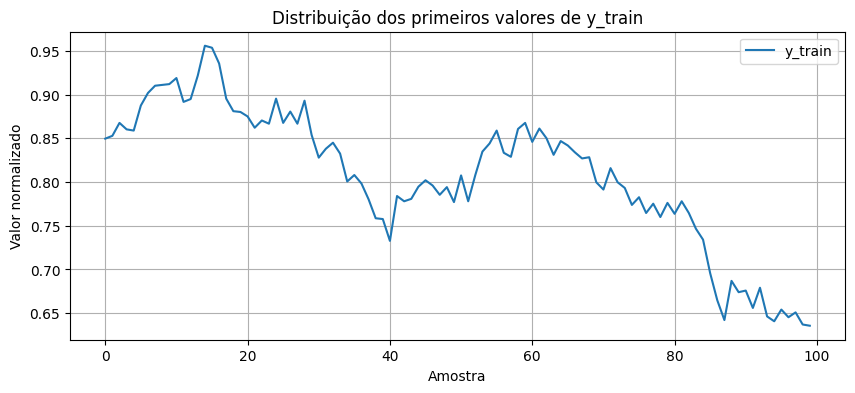

In [85]:
# 🔍 Verificar se y_train tem variação significativa
plt.figure(figsize=(10, 4))
plt.plot(y_train[:100], label='y_train')
plt.title('Distribuição dos primeiros valores de y_train')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

### Definição da arquitetura LSTM-GRU

A arquitetura híbrida é mantida para avaliar se a combinação entre LSTM e GRU consegue absorver um espaço de entrada mais complexo sem perder capacidade de generalização. A hipótese metodológica é que a representação latente se torne mais consistente quando a rede recebe informações técnicas e macroeconômicas de forma conjunta.


In [86]:
class LSTM_GRU_Model(nn.Module):
    def __init__(self, input_size, hidden_lstm=64, hidden_gru=32):
        super().__init__()

        # 🧠 LSTM: aprende padrões de longo prazo na série temporal
        # input_size: número de features por time step (ex: Close, RSI, EMA...)
        # hidden_lstm: número de neurônios na camada LSTM
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_lstm, batch_first=True)
        # self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True)

        # 🔁 GRU: refina as representações aprendidas pela LSTM
        # Recebe como entrada a saída da LSTM
        self.gru = nn.GRU(input_size=hidden_lstm, hidden_size=hidden_gru, batch_first=True)

        # Camada densa final: transforma o hidden final da GRU em uma predição
        self.fc = nn.Linear(hidden_gru, 1)

    def forward(self, x):

        # LSTM layer
        out_lstm1, _ = self.lstm1(x)  # Shape: (batch, seq_len, hidden_lstm)
        # out_lstm2, _ = self.lstm2(x)  # Shape: (batch, seq_len, hidden_lstm)

        # GRU layer
        out_gru, _ = self.gru(out_lstm1)  # Shape: (batch, seq_len, hidden_gru)
        # out_gru, _ = self.gru(out_lstm2)  # Shape: (batch, seq_len, hidden_gru)

        # Pegamos apenas a última saída temporal
        final_output = self.fc(out_gru[:, -1, :])  # Shape: (batch, 1)

        return final_output


In [87]:
# Detectar número de features automaticamente
input_size = X_train.shape[2]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTM_GRU_Model(input_size=X_train.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Feature Learning

Nesta etapa, o foco permanece no aprendizado estrutural da arquitetura. O interesse não é otimizar hiperparâmetros prematuramente, mas verificar se a rede consegue aprender padrões relevantes ao distinguir, ao menos parcialmente, movimentos associados ao ativo e movimentos relacionados ao ambiente cambial.


## Treinamento do modelo

O treinamento com validação permite observar se a inclusão da externalidade cambial melhora a capacidade preditiva sem comprometer a estabilidade do ajuste. Somente após essa verificação estrutural a etapa de otimização se torna metodologicamente justificável.


Epoch  1: Train Loss = 0.013858, Val Loss = 0.000944
Epoch  2: Train Loss = 0.001925, Val Loss = 0.002384
Epoch  3: Train Loss = 0.001280, Val Loss = 0.001448
Epoch  4: Train Loss = 0.000945, Val Loss = 0.001679
Epoch  5: Train Loss = 0.000693, Val Loss = 0.002539
Epoch  6: Train Loss = 0.000407, Val Loss = 0.002328
Epoch  7: Train Loss = 0.000415, Val Loss = 0.002879
Epoch  8: Train Loss = 0.000412, Val Loss = 0.003084
Epoch  9: Train Loss = 0.000352, Val Loss = 0.001531
Epoch 10: Train Loss = 0.000323, Val Loss = 0.000825
Epoch 11: Train Loss = 0.000276, Val Loss = 0.002167
Epoch 12: Train Loss = 0.000217, Val Loss = 0.001946
Epoch 13: Train Loss = 0.000179, Val Loss = 0.001023
Epoch 14: Train Loss = 0.000216, Val Loss = 0.000529
Epoch 15: Train Loss = 0.000187, Val Loss = 0.001095
Epoch 16: Train Loss = 0.000168, Val Loss = 0.001060
Epoch 17: Train Loss = 0.000134, Val Loss = 0.000929
Epoch 18: Train Loss = 0.000232, Val Loss = 0.000419
Epoch 19: Train Loss = 0.000230, Val Loss = 0.

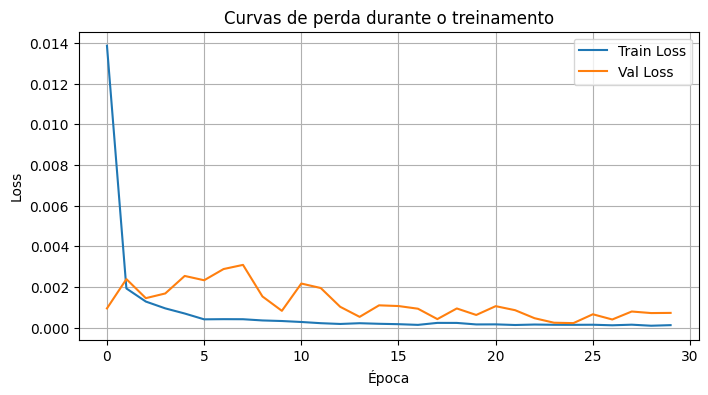

In [88]:
# 🔁 Treinamento com validação por época + melhor modelo salvo
from copy import deepcopy
best_val_loss = float('inf')
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(1, 31):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # Validação
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            val_loss = criterion(preds, yb)
            val_batch_losses.append(val_loss.item())
    val_loss = np.mean(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:2d}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    # Salvar melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

# Restaurar melhor modelo após o treinamento
model.load_state_dict(best_model_state)

# Plot das curvas de perda
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Curvas de perda durante o treinamento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

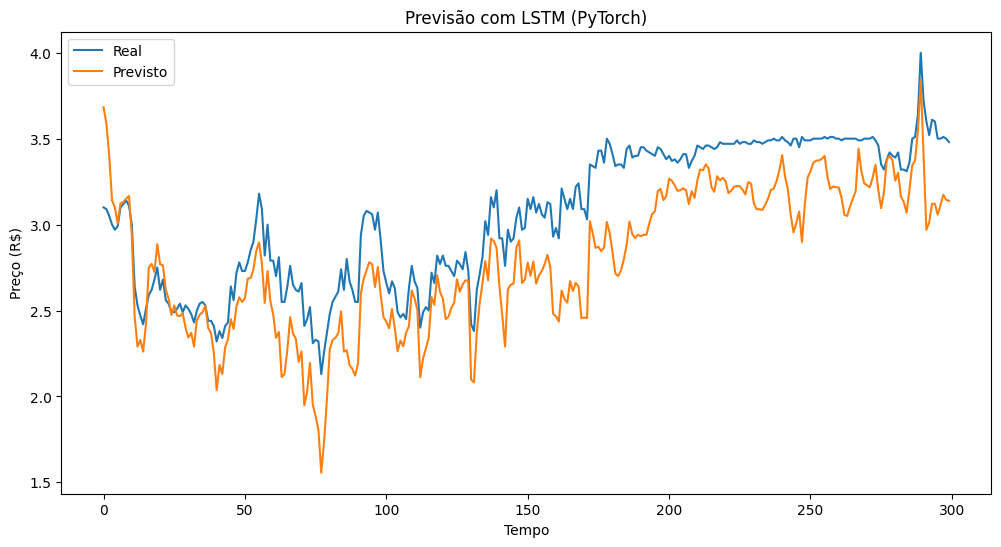

In [89]:
# Avaliação com correção para scaler multivariado
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds.extend(out.cpu().numpy())

# Ajustar shape para inverse_transform apenas da feature alvo
preds = np.array(preds)
preds_full = np.zeros((len(preds), scaler.n_features_in_))
actual_full = np.zeros((len(y_test), scaler.n_features_in_))
preds_full[:, 0] = preds[:, 0]
actual_full[:, 0] = y_test

preds_inverse = scaler.inverse_transform(preds_full)[:, 0]
actual_inverse = scaler.inverse_transform(actual_full)[:, 0]

# Plot
plt.figure(figsize=(12,6))
plt.plot(actual_inverse, label='Real')
plt.plot(preds_inverse, label='Previsto')
plt.legend()
plt.title('Previsão com LSTM (PyTorch)')
plt.xlabel('Tempo')
plt.ylabel('Preço (R$)')
plt.show()

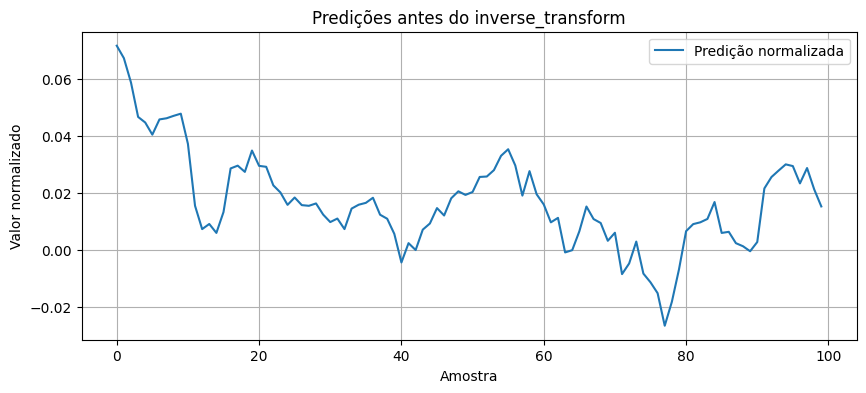

Predição (normalizada) - min: -0.0265, max: 0.0792, média: 0.0308


In [90]:
# 🧪 Diagnóstico: distribuição das predições normalizadas
plt.figure(figsize=(10, 4))
plt.plot(preds[:100], label='Predição normalizada')
plt.title('Predições antes do inverse_transform')
plt.xlabel('Amostra')
plt.ylabel('Valor normalizado')
plt.grid()
plt.legend()
plt.show()

print(f"Predição (normalizada) - min: {preds.min():.4f}, max: {preds.max():.4f}, média: {preds.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


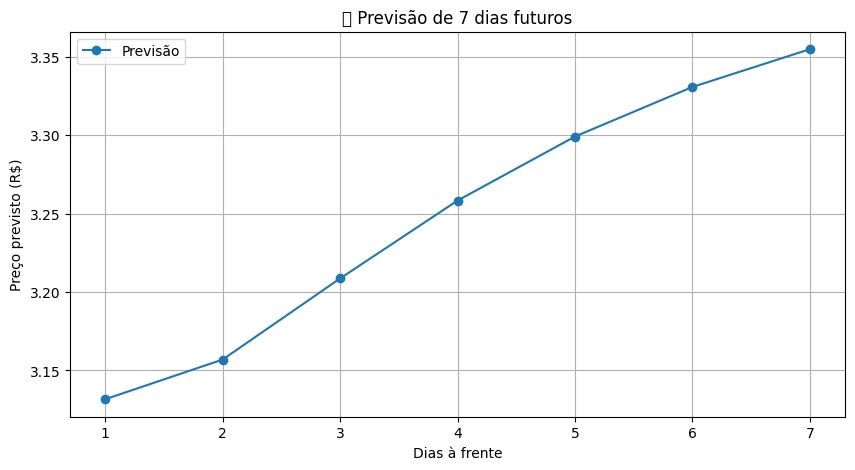

Dia +1: R$ 3.13
Dia +2: R$ 3.16
Dia +3: R$ 3.21
Dia +4: R$ 3.26
Dia +5: R$ 3.30
Dia +6: R$ 3.33
Dia +7: R$ 3.35


In [91]:
# 🧠 Previsão de múltiplos dias à frente
model.eval()
n_future = 7  # número de dias a prever

# Última sequência disponível
last_sequence = data[-seq_len:].values
last_scaled = scaler.transform(last_sequence)
future_preds = []

# Preparar o primeiro input [1, seq_len, n_features]
current_input = torch.tensor(last_scaled, dtype=torch.float32).unsqueeze(0).to(device)

for _ in range(n_future):
    with torch.no_grad():
        next_pred = model(current_input)
        pred_val = next_pred.cpu().numpy()[0, 0]
        future_preds.append(pred_val)

    # Preparar próxima entrada
    # Manter todas as features da última linha, mas sobrescrever o target (índice 0)
    next_step = current_input[0, -1, :].cpu().numpy()
    next_step[0] = pred_val  # Substitui apenas o target
    next_step = next_step.reshape(1, -1)

    # Construir nova sequência deslocando uma posição à frente
    next_sequence = torch.cat([
        current_input[:, 1:, :],  # remove o primeiro dia
        torch.tensor(next_step, dtype=torch.float32).unsqueeze(0).to(device)  # adiciona novo dia
    ], dim=1)

    current_input = next_sequence

# Corrigir estrutura para inverse_transform
future_scaled_full = np.zeros((n_future, scaler.n_features_in_))
future_scaled_full[:, 0] = future_preds  # só preenche a coluna do target

# Inverte e extrai apenas o target original
future_prices = scaler.inverse_transform(future_scaled_full)[:, 0]

# Plot
plt.figure(figsize=(10,5))
plt.plot(range(1, n_future + 1), future_prices, marker='o', label='Previsão')
plt.title('📅 Previsão de 7 dias futuros')
plt.xlabel('Dias à frente')
plt.ylabel('Preço previsto (R$)')
plt.grid()
plt.legend()
plt.show()

# Mostrar os valores
for i, p in enumerate(future_prices):
    print(f"Dia +{i+1}: R$ {p:.2f}")

In [92]:
# ==================================================
# CÉLULA - MÉTRICAS DE AVALIAÇÃO DO MODELO
# ==================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Garantir arrays 1D
y_true = np.array(actual_inverse).reshape(-1)
y_pred = np.array(preds_inverse).reshape(-1)

# ------------------------------------------
# Métricas de regressão
# ------------------------------------------
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# Evitar divisão por zero no MAPE
mask_mape = y_true != 0
mape = np.mean(np.abs((y_true[mask_mape] - y_pred[mask_mape]) / y_true[mask_mape])) * 100

r2 = r2_score(y_true, y_pred)

# ------------------------------------------
# Métrica direcional
# ------------------------------------------
# Compara se o modelo acertou a direção do movimento
# usando a variação entre t-1 e t
real_diff = np.diff(y_true)
pred_diff = np.diff(y_pred)

direcao_real = np.sign(real_diff)
direcao_pred = np.sign(pred_diff)

directional_accuracy = np.mean(direcao_real == direcao_pred) * 100

# ------------------------------------------
# Baseline ingênua
# ------------------------------------------
# Previsão de hoje = valor de ontem
baseline_pred = y_true[:-1]
baseline_true = y_true[1:]

baseline_mae = mean_absolute_error(baseline_true, baseline_pred)
baseline_mse = mean_squared_error(baseline_true, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)

mask_baseline_mape = baseline_true != 0
baseline_mape = np.mean(
    np.abs((baseline_true[mask_baseline_mape] - baseline_pred[mask_baseline_mape]) / baseline_true[mask_baseline_mape])
) * 100

baseline_r2 = r2_score(baseline_true, baseline_pred)

baseline_real_diff = np.diff(baseline_true)
baseline_pred_diff = np.diff(baseline_pred)

baseline_directional_accuracy = np.mean(
    np.sign(baseline_real_diff) == np.sign(baseline_pred_diff)
) * 100

# ------------------------------------------
# Tabela resumo
# ------------------------------------------
metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "MAPE (%)", "R²", "Directional Accuracy (%)"],
    "LSTM": [mae, mse, rmse, mape, r2, directional_accuracy],
    "Baseline Ingênua": [
        baseline_mae,
        baseline_mse,
        baseline_rmse,
        baseline_mape,
        baseline_r2,
        baseline_directional_accuracy
    ]
})

print("=== MÉTRICAS DO MODELO ===")
display(metricas)

# ------------------------------------------
# Interpretação simples
# ------------------------------------------
print("Resumo rápido:")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.6f}")
print(f"Dir. Accuracy: {directional_accuracy:.2f}%")

=== MÉTRICAS DO MODELO ===


,Métrica,LSTM,Baseline Ingênua
0,MAE,0.275529,0.063010
1,MSE,0.099255,0.009172
2,RMSE,0.315048,0.095770
3,MAPE (%),9.041495,2.194259
4,R²,0.391872,0.943989
5,Directional Accuracy (%),66.889632,37.919463


Resumo rápido:
MAE  : 0.275529
RMSE : 0.315048
MAPE : 9.04%
R²   : 0.391872
Dir. Accuracy: 66.89%
